In [5]:
import numpy as np
import plotly.graph_objects as go

# ===============================
# Light Direction Vectors
# ===============================

lights = np.array([
    [-0.4514, -0.0946, -0.8873],
    [-0.0710, -0.3948, -0.9161],
    [ 0.3458, -0.0682, -0.9358],
    [-0.0677,  0.2590, -0.9636]
])

labels = ["L1", "L2", "L3", "L4"]

# ===============================
# Compute Angles
# ===============================

azimuth = np.degrees(np.arctan2(lights[:,1], lights[:,0]))
zenith = np.degrees(np.arccos(np.abs(lights[:,2])))

# ===============================
# Create Hemisphere Wireframe
# ===============================

u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi/2, 50)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# ===============================
# 3D Figure
# ===============================

fig = go.Figure()

# Hemisphere surface (transparent)
fig.add_trace(go.Surface(
    x=x, y=y, z=z,
    opacity=0.3,
    showscale=False,
    colorscale=[[0, 'lightgray'], [1, 'lightgray']]
))

# Coordinate axes
axis_length = 1.2

fig.add_trace(go.Scatter3d(
    x=[0, axis_length], y=[0,0], z=[0,0],
    mode='lines', name='X-axis'
))
fig.add_trace(go.Scatter3d(
    x=[0,0], y=[0, axis_length], z=[0,0],
    mode='lines', name='Y-axis'
))
fig.add_trace(go.Scatter3d(
    x=[0,0], y=[0,0], z=[0, axis_length],
    mode='lines', name='Z-axis'
))

# Light vectors
for i, l in enumerate(lights):
    fig.add_trace(go.Scatter3d(
        x=[0, l[0]],
        y=[0, l[1]],
        z=[0, l[2]],
        mode='lines+markers',
        name=labels[i],
        hovertemplate=
        f"<b>{labels[i]}</b><br>"
        f"Azimuth (φ): {azimuth[i]:.2f}°<br>"
        f"Zenith (θ): {zenith[i]:.2f}°<br>"
        f"Vector: {l}"
    ))

fig.update_layout(
    title="Interactive Light Direction Visualization",
    scene=dict(
        xaxis=dict(range=[-1,1]),
        yaxis=dict(range=[-1,1]),
        zaxis=dict(range=[-1,1]),
        aspectmode='cube'
    ),
    width=800,
    height=800
)

fig.show()

# ===============================
# Polar Plot (Azimuth vs Zenith)
# ===============================

polar_fig = go.Figure()

polar_fig.add_trace(go.Scatterpolar(
    r=zenith,
    theta=azimuth,
    mode='markers+text',
    text=labels,
    textposition='top center'
))

polar_fig.update_layout(
    title="Interactive Azimuth–Zenith Distribution",
    polar=dict(
        radialaxis=dict(title="Zenith (°)"),
        angularaxis=dict(direction="clockwise")
    ),
    width=700,
    height=700
)

polar_fig.show()

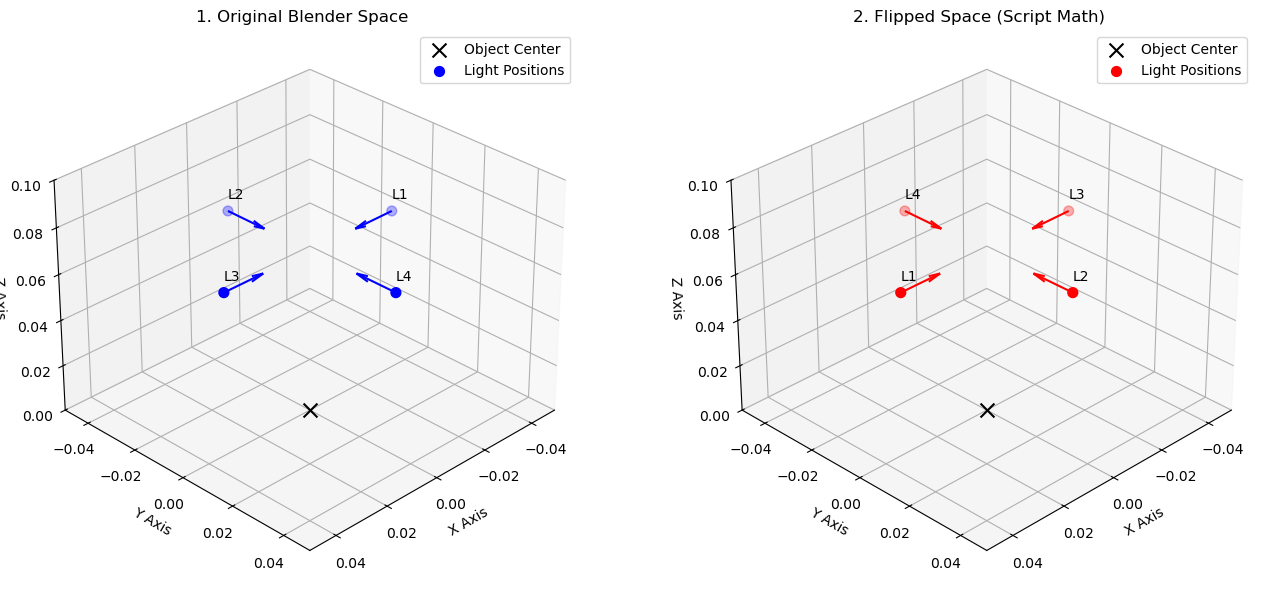

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Original Blender Coordinates ---
pos_blender = np.array([
    [-0.03325, 0.0, 0.07025],
    [ 0.0, -0.03325, 0.07025],
    [ 0.03325, 0.0, 0.07025],
    [ 0.0, 0.03325, 0.07025]
])

dir_blender = np.array([
    [ 1,  0, 0], 
    [ 0,  1, 0], 
    [-1,  0, 0], 
    [ 0, -1, 0]
])

# --- 2. Flipped Coordinates (For the Script) ---
# We negate X and Y, but keep Z the same
pos_flipped = pos_blender.copy()
pos_flipped[:, 0] = -pos_flipped[:, 0]
pos_flipped[:, 1] = -pos_flipped[:, 1]

dir_flipped = dir_blender.copy()
dir_flipped[:, 0] = -dir_flipped[:, 0]
dir_flipped[:, 1] = -dir_flipped[:, 1]

# --- 3. Visualization ---
fig = plt.figure(figsize=(14, 6))

def plot_lights(ax, positions, directions, title, color):
    ax.set_title(title)
    # Plot origin (Object center)
    ax.scatter(0, 0, 0, color='black', marker='x', s=100, label='Object Center')
    
    # Plot lights
    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], color=color, s=50, label='Light Positions')
    
    # Plot direction vectors (quiver)
    length = 0.015
    ax.quiver(positions[:, 0], positions[:, 1], positions[:, 2],
              directions[:, 0], directions[:, 1], directions[:, 2],
              color=color, length=length, normalize=True, arrow_length_ratio=0.3)
    
    # Labels
    for i in range(4):
        ax.text(positions[i, 0], positions[i, 1], positions[i, 2] + 0.005, f"L{i+1}", color='black')

    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    
    # Ensure consistent scale
    ax.set_xlim([-0.05, 0.05])
    ax.set_ylim([-0.05, 0.05])
    ax.set_zlim([0, 0.1])
    ax.view_init(elev=30, azim=45)
    ax.legend()

# Plot Blender System
ax1 = fig.add_subplot(121, projection='3d')
plot_lights(ax1, pos_blender, dir_blender, "1. Original Blender Space", "blue")

# Plot Flipped System
ax2 = fig.add_subplot(122, projection='3d')
plot_lights(ax2, pos_flipped, dir_flipped, "2. Flipped Space (Script Math)", "red")

plt.tight_layout()
plt.show()